In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/radheshyamkollipara/bank-customer-churn/Customer-Churn-Records.csv


# 📉 Bank Customer Exited Dataset

## 🎯 Objective
Customer churn is a critical problem in the telecom industry. Retaining existing customers is significantly more cost-effective than acquiring new ones.

The objective of this project is to build a machine learning model that can accurately predict whether a customer is likely to Exited, enabling proactive retention strategies.

---

## ⚠️ Problem Challenge
The dataset is **imbalanced**:
- 79.62% Non-Exited
- 20.38% Exited

This makes **accuracy misleading**, so the focus is on:
- ROC-AUC
- Recall (Churn Detection)
- Precision-Recall Balance

---

## 🧪 Approach
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Encoding & Scaling
- Model Training 
- Model Comparison using multiple metrics

---

## 🤖 Models Used
- Logistic Regression
- DecisionTreeClassifier
- RandomForestClassifier
- GradientBoostingClassifier
- XGBoostClassifier
- CatBoostClassifier
- LGBMClassifier

In [2]:
#======================================== Define Modules ===========================================#
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score
import joblib

In [3]:
#=================================== Remove All Warnings ===================================#
warnings.filterwarnings('ignore')

In [4]:
#===================================== Load Dataset =======================================#
loan_df = pd.read_csv("/kaggle/input/datasets/radheshyamkollipara/bank-customer-churn/Customer-Churn-Records.csv")

# **Preprocessing Dataset**

In [5]:
#===================================== Preview The Dataset =====================================#
loan_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
#========================================= Shape Of Dataset ==============================================#
loan_df.shape

(10000, 18)

In [7]:
#================================ How Many Null Values Present In Dataset ================================# 
loan_df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [8]:
#=============================== How Many Duplicates Values Present In Dataset ==============================# 
loan_df.duplicated().sum()

np.int64(0)

In [9]:
#================================ How Many Unique Values Present In Dataset ==================================# 
loan_df.nunique()

RowNumber             10000
CustomerId            10000
Surname                2932
CreditScore             460
Geography                 3
Gender                    2
Age                      70
Tenure                   11
Balance                6382
NumOfProducts             4
HasCrCard                 2
IsActiveMember            2
EstimatedSalary        9999
Exited                    2
Complain                  2
Satisfaction Score        5
Card Type                 4
Point Earned            785
dtype: int64

In [10]:
#=============================================== About Dataset ===============================================#
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [11]:
#==================================== Check Min,Max and Mean Etc..============================================#
loan_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [12]:
#========================== Remove The RowNumber and CustomerId Columns From The Dataset ======================# 
loan_df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace = True)

In [13]:
#==================================== Convert All Object Columns In Lower-Case ================================# 
object_columns = loan_df.select_dtypes(include = ['object']).columns
loan_df[object_columns] = loan_df[object_columns].apply(lambda x:x.str.lower())

In [14]:
#=============================== Convert All Object Columns In Category DataType =============================# 
object_columns = loan_df.select_dtypes(include = ['object']).columns
loan_df[object_columns] = loan_df[object_columns].apply(lambda x:x.astype('category'))

In [15]:
#======================================= Check All Category Columns Types ====================================#
categorical_columns = loan_df[['Geography','Gender','Card Type']]
for cols in categorical_columns:
    print("#=============================================#")
    print(loan_df[cols].value_counts())
    print("#=============================================#")

#=============================================#
Geography
france     5014
germany    2509
spain      2477
Name: count, dtype: int64
#=============================================#
#=============================================#
Gender
male      5457
female    4543
Name: count, dtype: int64
#=============================================#
#=============================================#
Card Type
diamond     2507
gold        2502
silver      2496
platinum    2495
Name: count, dtype: int64
#=============================================#


In [16]:
#========================================= Check All Numeric Columns Types ======================================#
numeric_columns = loan_df[['NumOfProducts','HasCrCard','IsActiveMember','Exited','Complain','Satisfaction Score']]
for num_cols in numeric_columns:
    print("#=============================================#")
    print(loan_df[num_cols].value_counts())
    print("#=============================================#")

#=============================================#
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
#=============================================#
#=============================================#
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
#=============================================#
#=============================================#
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
#=============================================#
#=============================================#
Exited
0    7962
1    2038
Name: count, dtype: int64
#=============================================#
#=============================================#
Complain
0    7956
1    2044
Name: count, dtype: int64
#=============================================#
#=============================================#
Satisfaction Score
3    2042
2    2014
4    2008
5    2004
1    1932
Name: count, dtype: int64
#=============================================#


#====================================================#


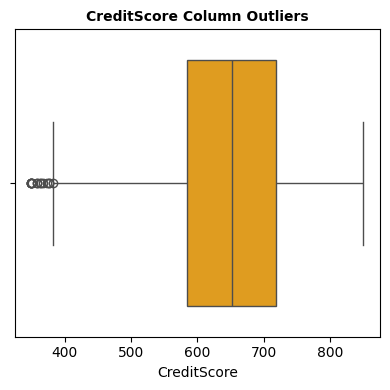

#====================================================#
#====================================================#


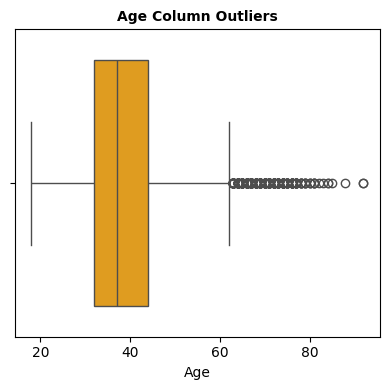

#====================================================#
#====================================================#


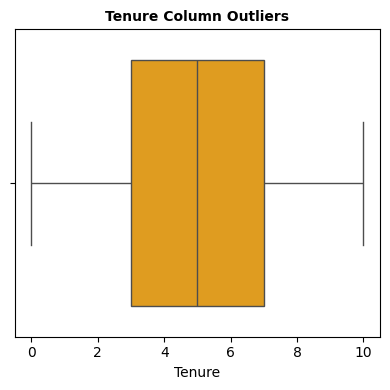

#====================================================#
#====================================================#


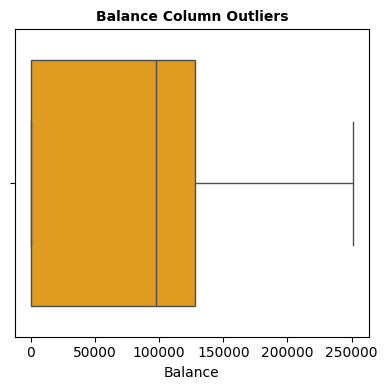

#====================================================#
#====================================================#


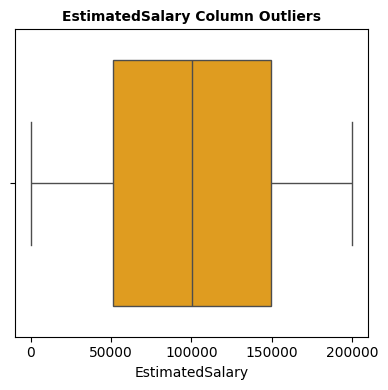

#====================================================#
#====================================================#


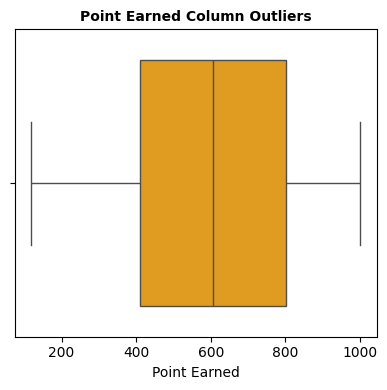

#====================================================#
Total: 374 Outliers Present In Dataset


In [17]:
#============================== Check How Many Outlier Present In Numeric Columns ==============================#
Outlier_data = loan_df.copy()
Outlier_box = set()
columns = ['CreditScore','Age','Tenure','Balance','EstimatedSalary','Point Earned']
for col in columns:
    Q1 = Outlier_data[col].quantile(0.25)
    Q3 = Outlier_data[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_bound = Q1 - 1.5 * IQR
    Upper_bound = Q3 + 1.5 * IQR
    Outliers = Outlier_data[(Outlier_data[col] < Lower_bound) | (Outlier_data[col] > Upper_bound)]
    Outlier_box.update(Outliers.index)
    print('#====================================================#')
    plt.figure(figsize = (4,4))
    plt.title(f'{col} Column Outliers',fontsize = 10,fontweight = 'bold')
    sns.boxplot(x = Outlier_data[col],color = 'orange')
    plt.tight_layout()
    plt.show()
    print('#====================================================#')
print(f'Total: {len(Outlier_box)} Outliers Present In Dataset')

In [18]:
#=================================== Check The Correlation With Exited Column =================================#
loan_df.select_dtypes(include = ['number']).corr()['Exited'].sort_values(ascending = False)

Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64

In [19]:
#============================================= Filtring Dataset ===========================================#
#================================== How Many Male Person Salary Has More Than 30000 ============================#
loan_df[(loan_df['Gender'] == 'male') & (loan_df['EstimatedSalary'] > 30000)].shape[0]
print("Total 4644 Male Person Salary Has More Than 30000")

Total 4644 Male Person Salary Has More Than 30000


In [20]:
#================================= How Many Female Person Salary Has More Than 30000 =========================#
loan_df[(loan_df['Gender'] == 'female') & (loan_df['EstimatedSalary'] > 30000)].shape[0]
print("Total 3878 Female Person Salary Has More Than 30000")

Total 3878 Female Person Salary Has More Than 30000


In [21]:
#================================ How Many Female Person CreditScore Has More Than 600 =========================#
loan_df[(loan_df['Gender'] == 'female') & (loan_df['CreditScore'] > 600)].shape[0]
print("Total 3161 Female Person CreditScore Has More Than 600")

Total 3161 Female Person CreditScore Has More Than 600


In [22]:
#================================ How Many Male Person CreditScore Has More Than 600 =========================#
loan_df[(loan_df['Gender'] == 'male') & (loan_df['CreditScore'] > 600)].shape[0]
print("Total 3773 Male Person CreditScore Has More Than 600")

Total 3773 Male Person CreditScore Has More Than 600


In [23]:
#====================================== Preview The Preprocessing Dataset ======================================#
loan_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,france,female,42,2,0.00,1,1,1,101348.88,1,1,2,diamond,464
1,608,spain,female,41,1,83807.86,1,0,1,112542.58,0,1,3,diamond,456
2,502,france,female,42,8,159660.80,3,1,0,113931.57,1,1,3,diamond,377
3,699,france,female,39,1,0.00,2,0,0,93826.63,0,0,5,gold,350
4,850,spain,female,43,2,125510.82,1,1,1,79084.10,0,0,5,gold,425


# # **Exploratory Data Analysis**

## **univariate analysis**

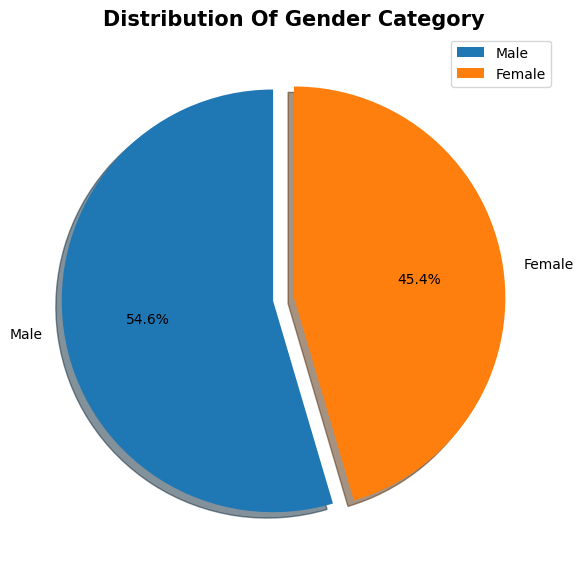

In [24]:
#====================================== Distribution Of Gender Category ======================================#
plt.figure(figsize = (6,7))
plt.title("Distribution Of Gender Category",fontsize = 15,fontweight = 'bold')
plt.pie(loan_df['Gender'].value_counts(),startangle = 90,autopct = '%1.1f%%',shadow = True,explode = [0.1,0],labels = ['Male','Female'])
plt.legend()
plt.tight_layout()
plt.savefig('Distribution Of Gender Category.png')
plt.show()

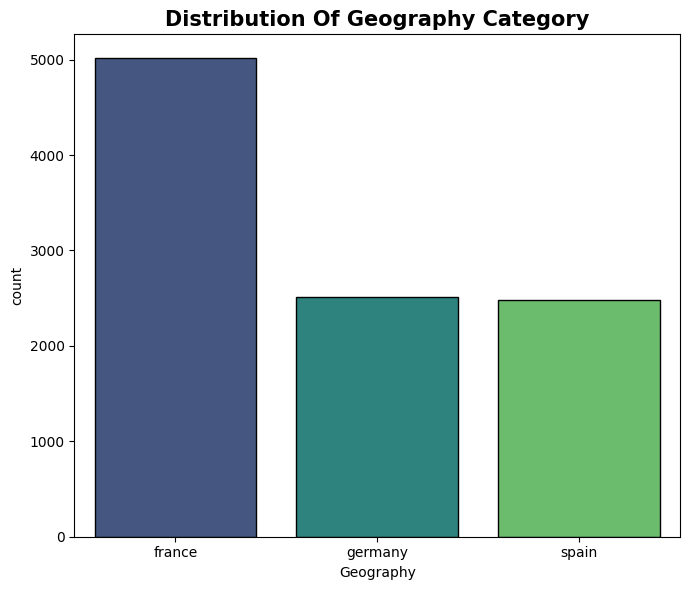

In [25]:
#====================================== Distribution Of Geography Category ======================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Geography Category",fontsize = 15,fontweight = 'bold')
sns.countplot(data = loan_df,x = 'Geography',edgecolor = 'black',palette = 'viridis')
plt.tight_layout()
plt.savefig('Distribution Of Geography Category.png')
plt.show()

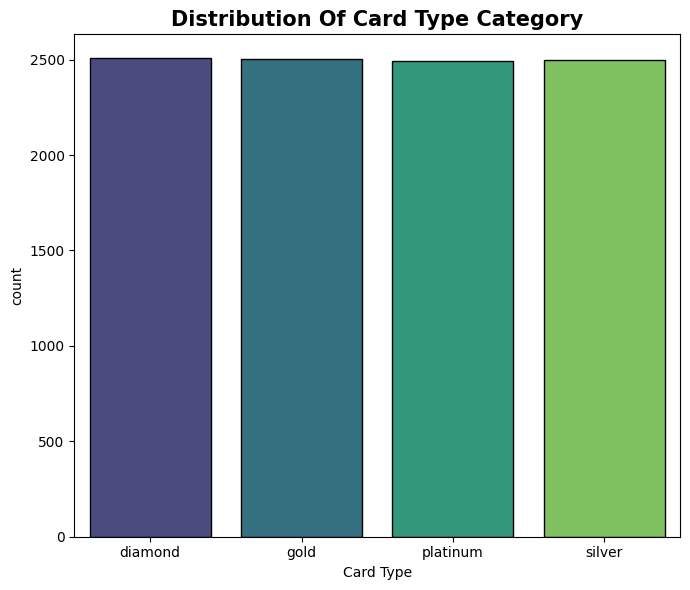

In [26]:
#====================================== Distribution Of Card Type Category ======================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Card Type Category",fontsize = 15,fontweight = 'bold')
sns.countplot(data = loan_df,x = 'Card Type',edgecolor = 'black',palette = 'viridis')
plt.tight_layout()
plt.savefig('Distribution Of Card Type Category.png')
plt.show()

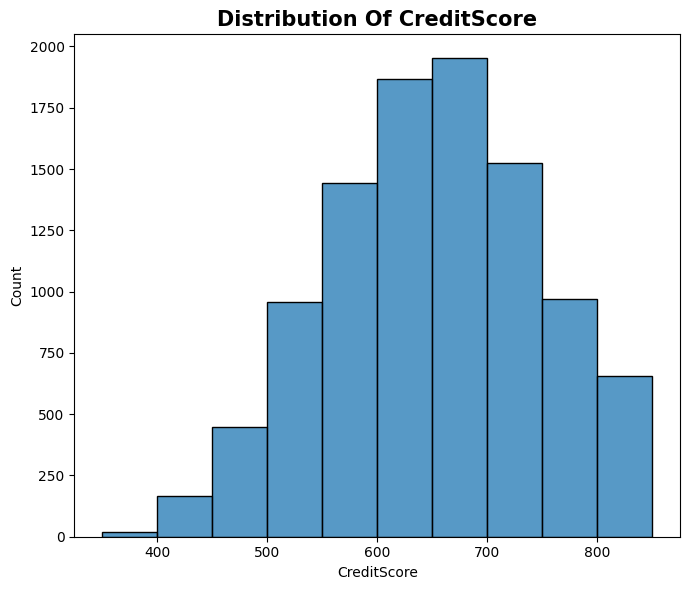

In [27]:
#========================================= Distribution Of CreditScore =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of CreditScore",fontsize = 15,fontweight = 'bold')
sns.histplot(data = loan_df,x = 'CreditScore',bins = 10,edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of CreditScore.png")
plt.show()

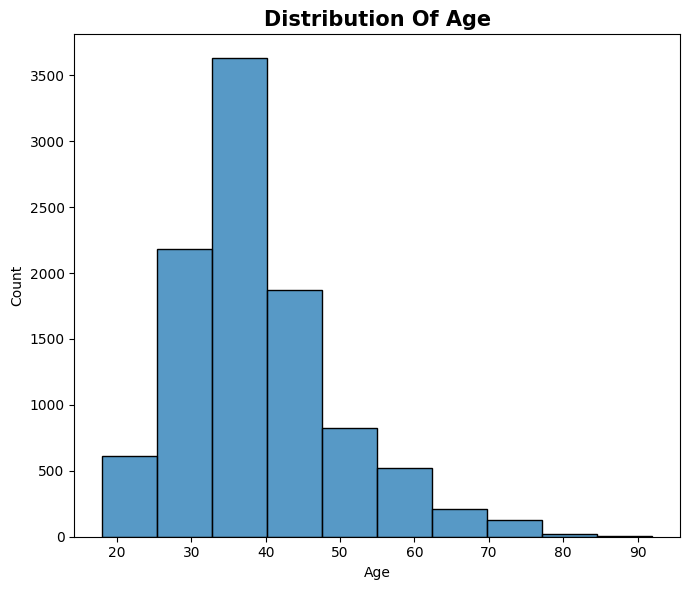

In [28]:
#========================================= Distribution Of Age =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Age",fontsize = 15,fontweight = 'bold')
sns.histplot(data = loan_df,x = 'Age',bins = 10,edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of Age.png")
plt.show()

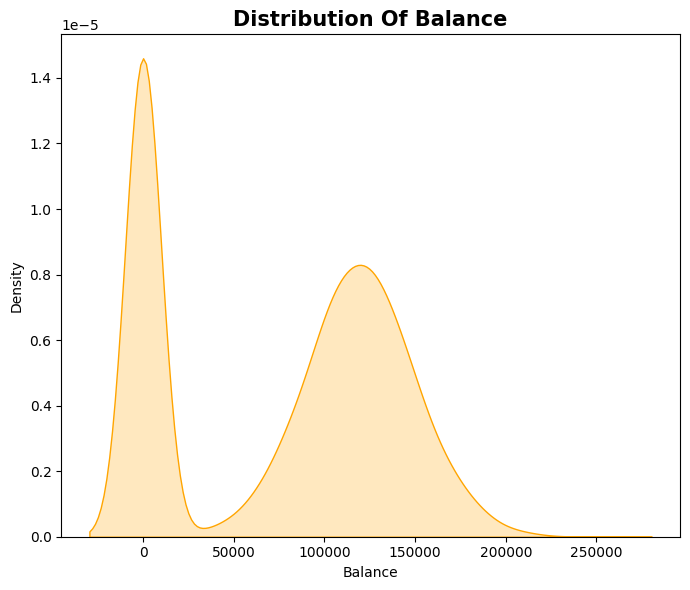

In [29]:
#========================================= Distribution Of Balance =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Balance",fontsize = 15,fontweight = 'bold')
sns.kdeplot(data = loan_df,x = 'Balance',fill = True,color = 'orange')
plt.tight_layout()
plt.savefig("Distribution Of Balance.png")
plt.show()

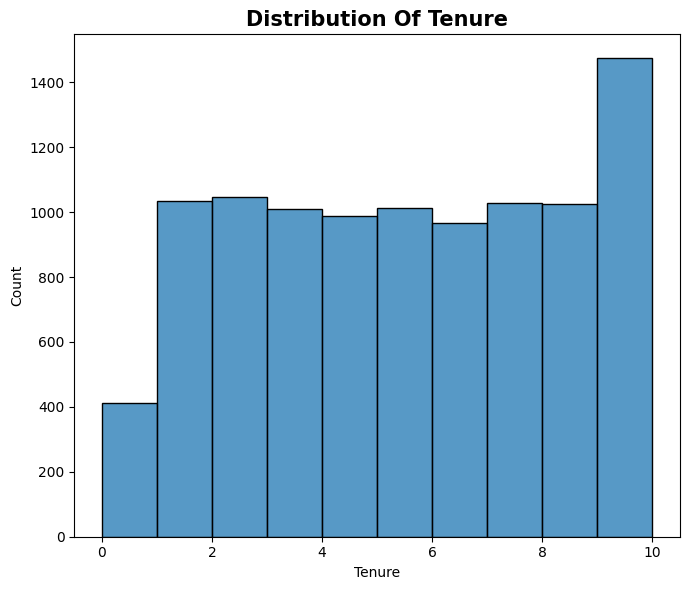

In [30]:
#========================================= Distribution Of Tenure =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Tenure",fontsize = 15,fontweight = 'bold')
sns.histplot(data = loan_df,x = 'Tenure',bins = 10,edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of Tenure.png")
plt.show()

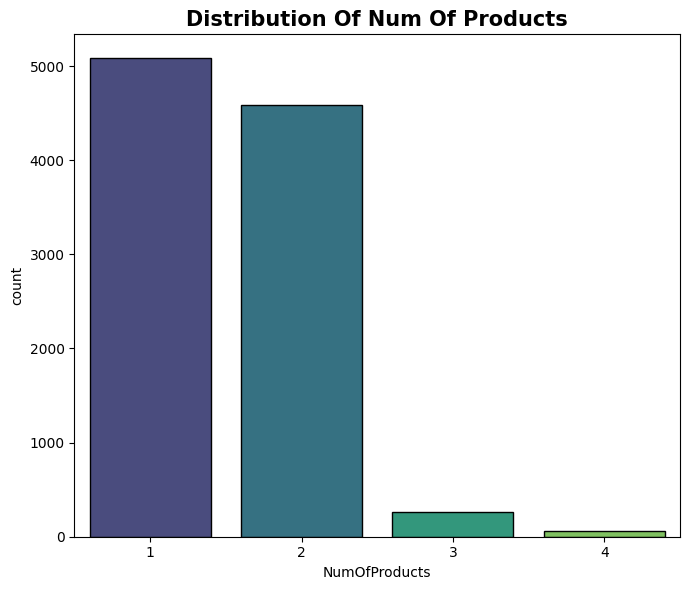

In [31]:
#========================================= Distribution Of Num_Of_Product ======================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Num Of Products",fontsize = 15,fontweight = 'bold')
sns.countplot(data = loan_df,x = 'NumOfProducts',palette = 'viridis',edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of NumOfProducts.png")
plt.show()

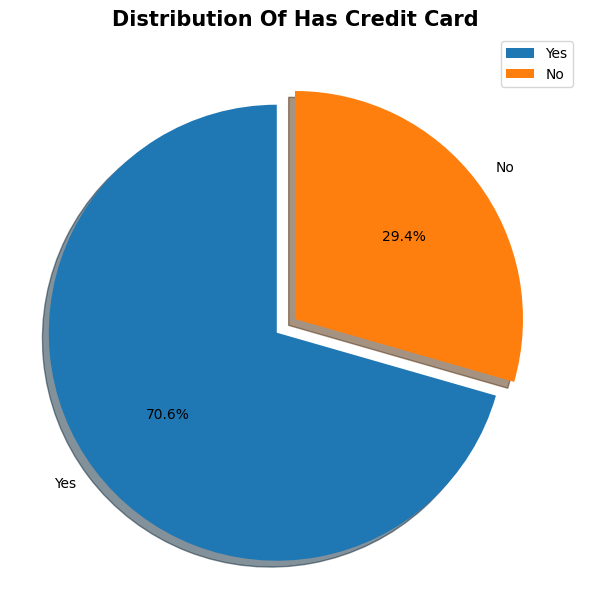

In [32]:
#======================================= Distribution Of Has Credit Card ========================================#
plt.figure(figsize = (6,7))
plt.title("Distribution Of Has Credit Card",fontsize = 15,fontweight = 'bold')
plt.pie(loan_df['HasCrCard'].value_counts(),startangle = 90,autopct = '%1.1f%%',shadow = True,explode = [0.1,0],labels = ['Yes','No'])
plt.legend()
plt.tight_layout()
plt.savefig('Distribution Of Has Credit Card.png')
plt.show()

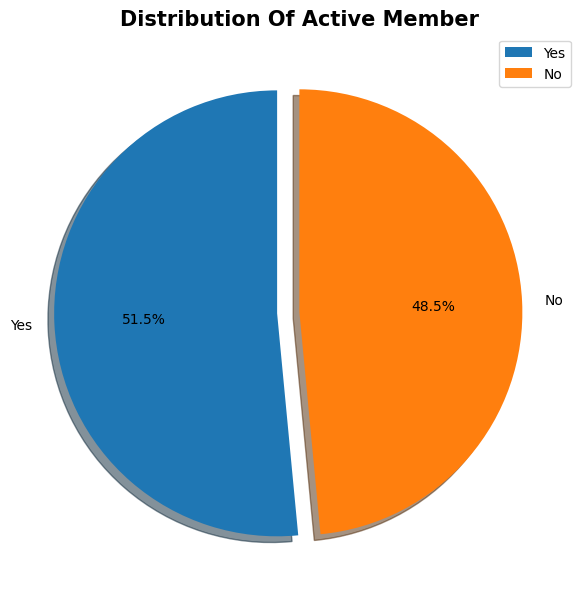

In [33]:
#======================================= Distribution Of Active Member ========================================#
plt.figure(figsize = (6,7))
plt.title("Distribution Of Active Member",fontsize = 15,fontweight = 'bold')
plt.pie(loan_df['IsActiveMember'].value_counts(),startangle = 90,autopct = '%1.1f%%',shadow = True,explode = [0.1,0],labels = ['Yes','No'])
plt.legend()
plt.tight_layout()
plt.savefig('Distribution Of Active Member.png')
plt.show()

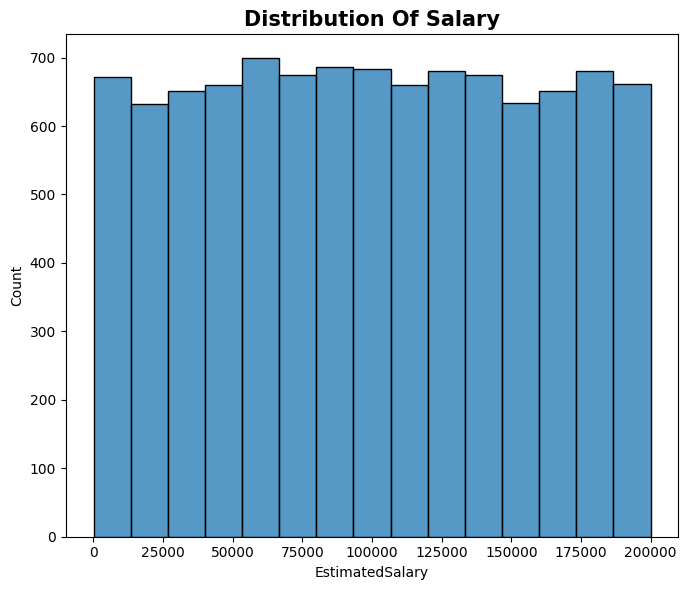

In [34]:
#========================================= Distribution Of Salary =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Salary",fontsize = 15,fontweight = 'bold')
sns.histplot(data = loan_df,x = 'EstimatedSalary',edgecolor = 'black',bins = 15)
plt.tight_layout()
plt.savefig("Distribution Of EstimatedSalary.png")
plt.show()

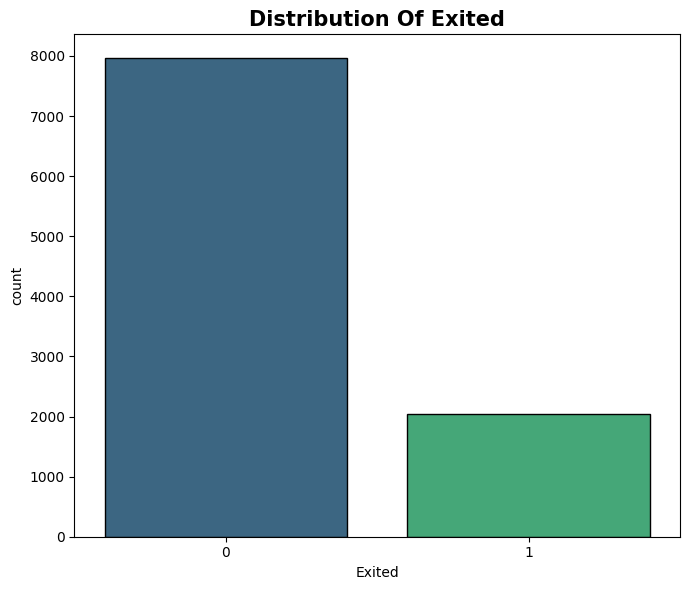

In [35]:
#========================================= Distribution Of Exited ======================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Exited",fontsize = 15,fontweight = 'bold')
sns.countplot(data = loan_df,x = 'Exited',palette = 'viridis',edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of Exited.png")
plt.show()

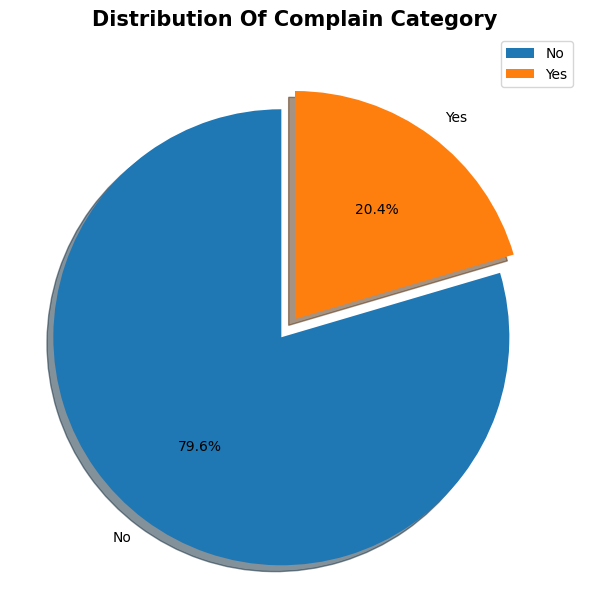

In [36]:
#====================================== Distribution Of Complain Category ======================================#
plt.figure(figsize = (6,7))
plt.title("Distribution Of Complain Category",fontsize = 15,fontweight = 'bold')
plt.pie(loan_df['Complain'].value_counts(),startangle = 90,autopct = '%1.1f%%',shadow = True,explode = [0.1,0],labels = ['No','Yes'])
plt.legend()
plt.tight_layout()
plt.savefig('Distribution Of Complain Category.png')
plt.show()

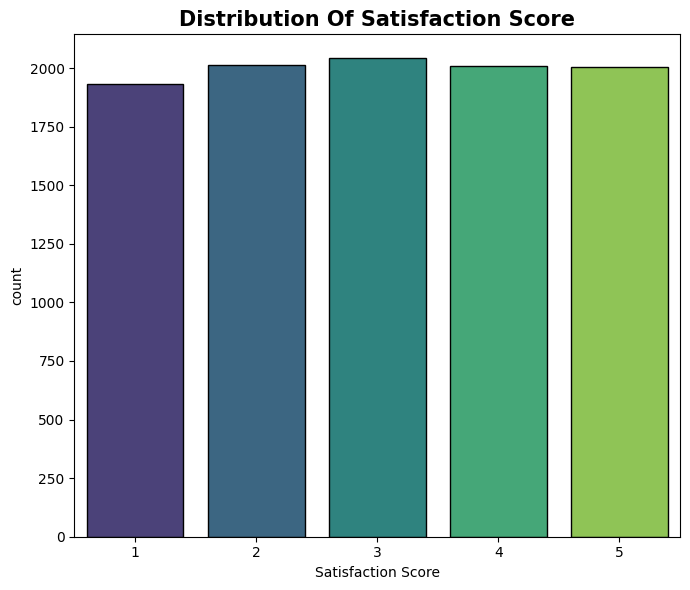

In [37]:
#====================================== Distribution Of Satisfaction Score ====================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Satisfaction Score",fontsize = 15,fontweight = 'bold')
sns.countplot(data = loan_df,x = 'Satisfaction Score',palette = 'viridis',edgecolor = 'black')
plt.tight_layout()
plt.savefig("Distribution Of Satisfaction Score.png")
plt.show()

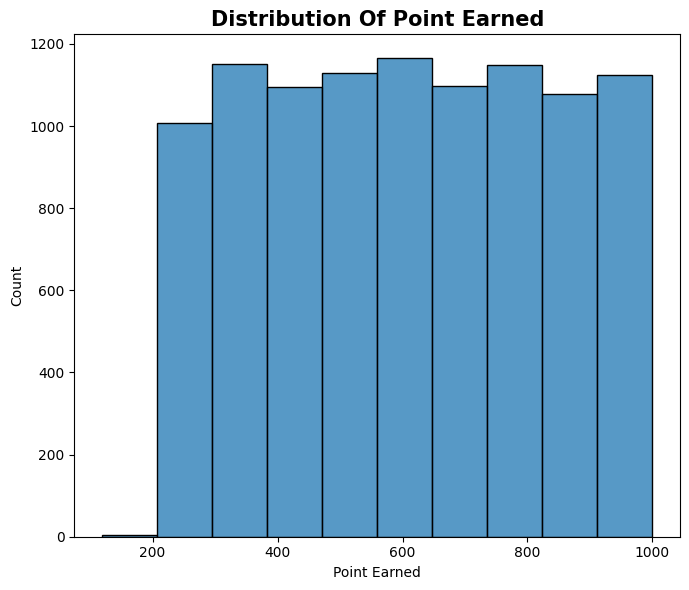

In [38]:
#========================================= Distribution Of Point Earned =========================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Point Earned",fontsize = 15,fontweight = 'bold')
sns.histplot(data = loan_df,x = 'Point Earned',edgecolor = 'black',bins = 10)
plt.tight_layout()
plt.savefig("Distribution Of Point Earned.png")
plt.show()

## **bivariate analysis**

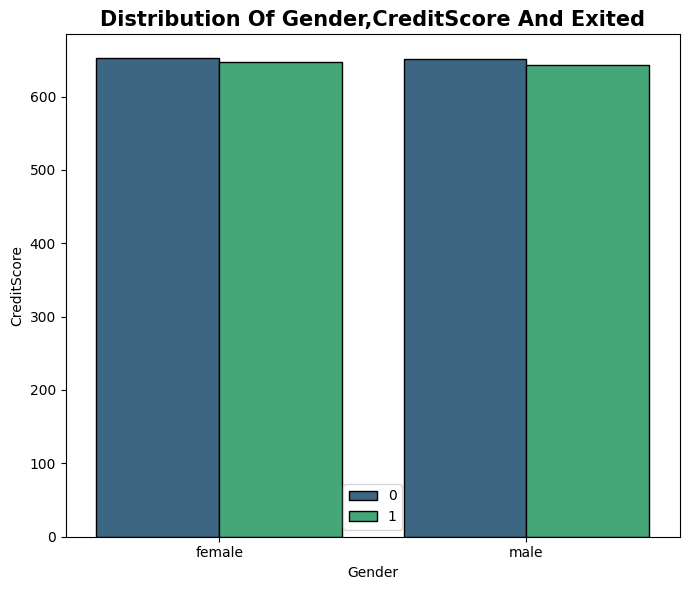

In [39]:
#================================== Distribution Of Gender,CreditScore And Exited ==============================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Gender,CreditScore And Exited",fontsize = 15,fontweight = 'bold')
sns.barplot(data = loan_df,x = 'Gender',y = 'CreditScore',hue = 'Exited',edgecolor = 'black',errorbar = None,palette = 'viridis')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution Of Gender,CreditScore And Exited.png")
plt.show()

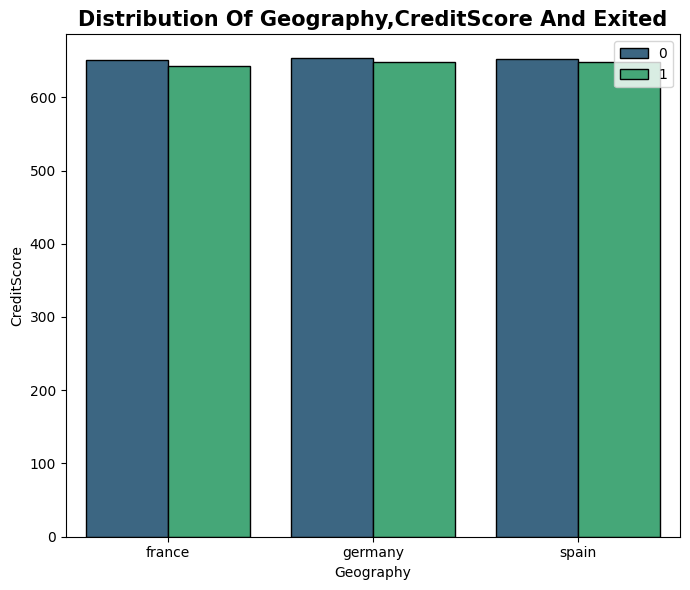

In [40]:
#================================== Distribution Of Geography,CreditScore And Exited ==============================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Geography,CreditScore And Exited",fontsize = 15,fontweight = 'bold')
sns.barplot(data = loan_df,x = 'Geography',y = 'CreditScore',hue = 'Exited',edgecolor = 'black',errorbar = None,palette = 'viridis')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution Of Geography,CreditScore And Exited.png")
plt.show()

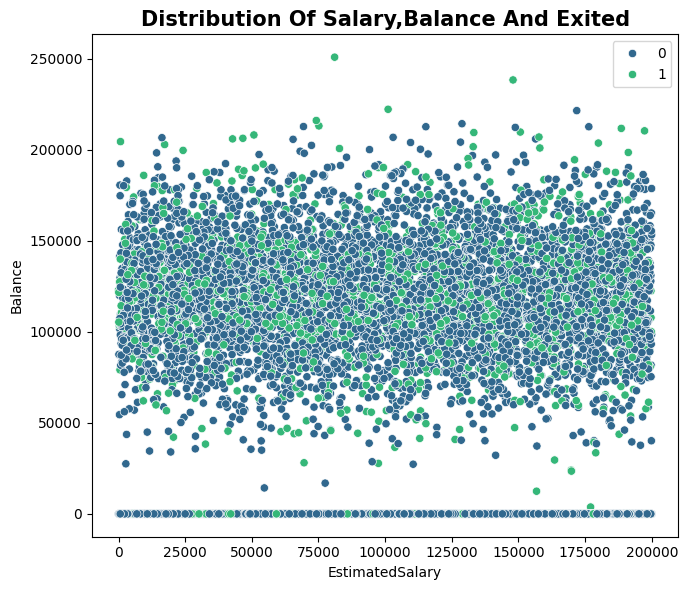

In [41]:
#================================== Distribution Of Salary,Balance And Exited ==================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Salary,Balance And Exited",fontsize = 15,fontweight = 'bold')
sns.scatterplot(data = loan_df,x = 'EstimatedSalary',y = 'Balance',hue = 'Exited',palette = 'viridis')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution Of Salary,Balance And Exited.png")
plt.show()

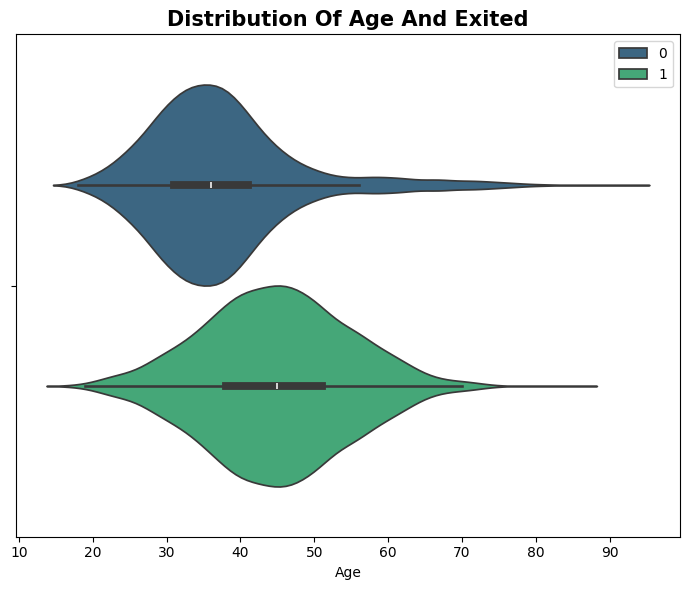

In [42]:
#=========================================== Distribution Of Age And Exited =====================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Age And Exited",fontsize = 15,fontweight = 'bold')
sns.violinplot(data = loan_df,x = 'Age',hue = 'Exited',fill = True,palette = 'viridis')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution Of Age And Exited.png")
plt.show()

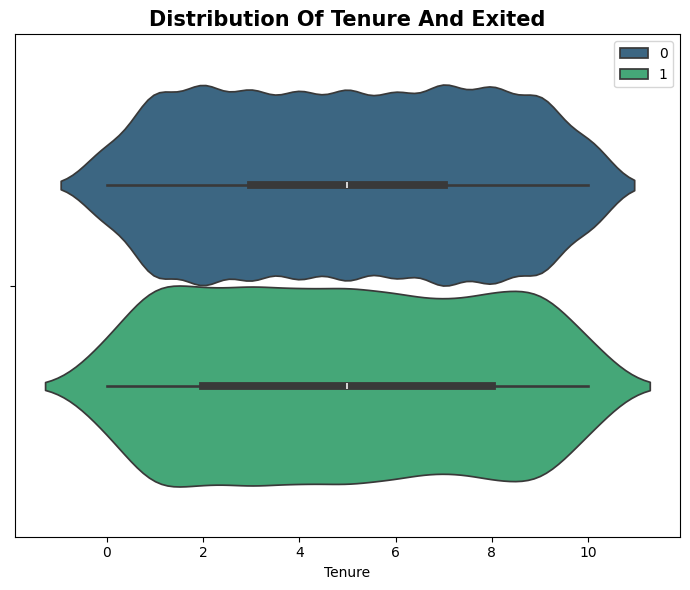

In [43]:
#=========================================== Distribution Of Tenure And Exited =====================================#
plt.figure(figsize = (7,6))
plt.title("Distribution Of Tenure And Exited",fontsize = 15,fontweight = 'bold')
sns.violinplot(data = loan_df,x = 'Tenure',hue = 'Exited',fill = True,palette = 'viridis')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution Of Tenure And Exited.png")
plt.show()

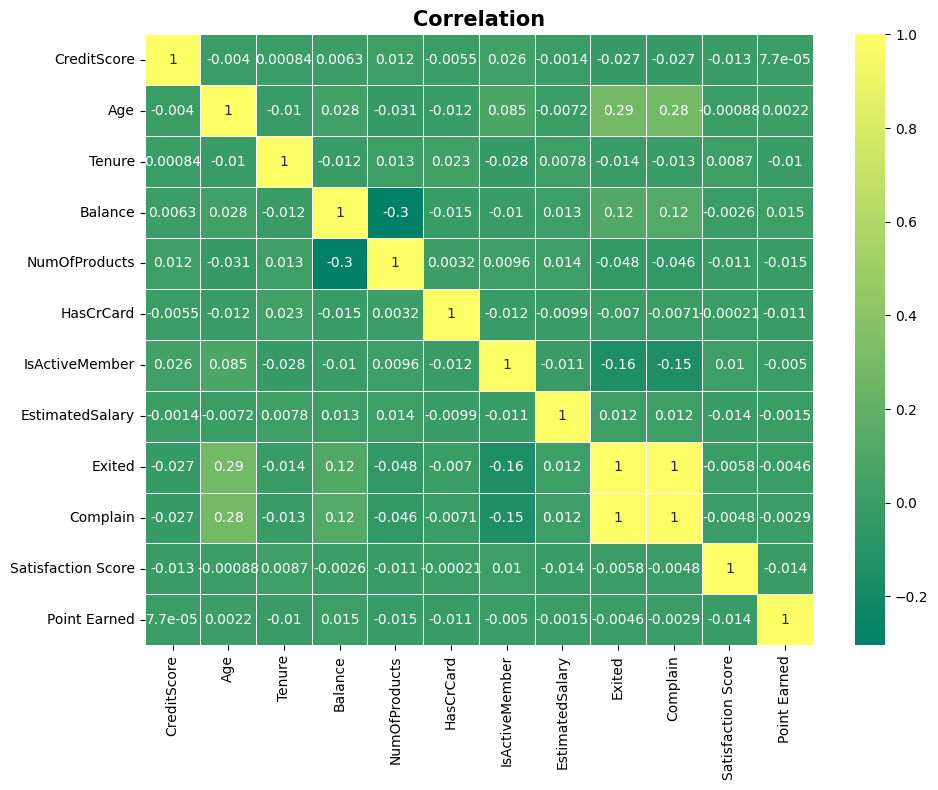

In [44]:
#======================================= Correlation with Exited Column ========================================#
correlation = loan_df.select_dtypes(include = ['number'])
correlation = correlation.corr()
plt.figure(figsize = (10,8))
plt.title("Correlation",fontsize = 15,fontweight = 'bold')
sns.heatmap(correlation,cmap = 'summer',annot = True,linewidths = 0.5)
plt.tight_layout()
plt.savefig('Correlation.png')
plt.show()

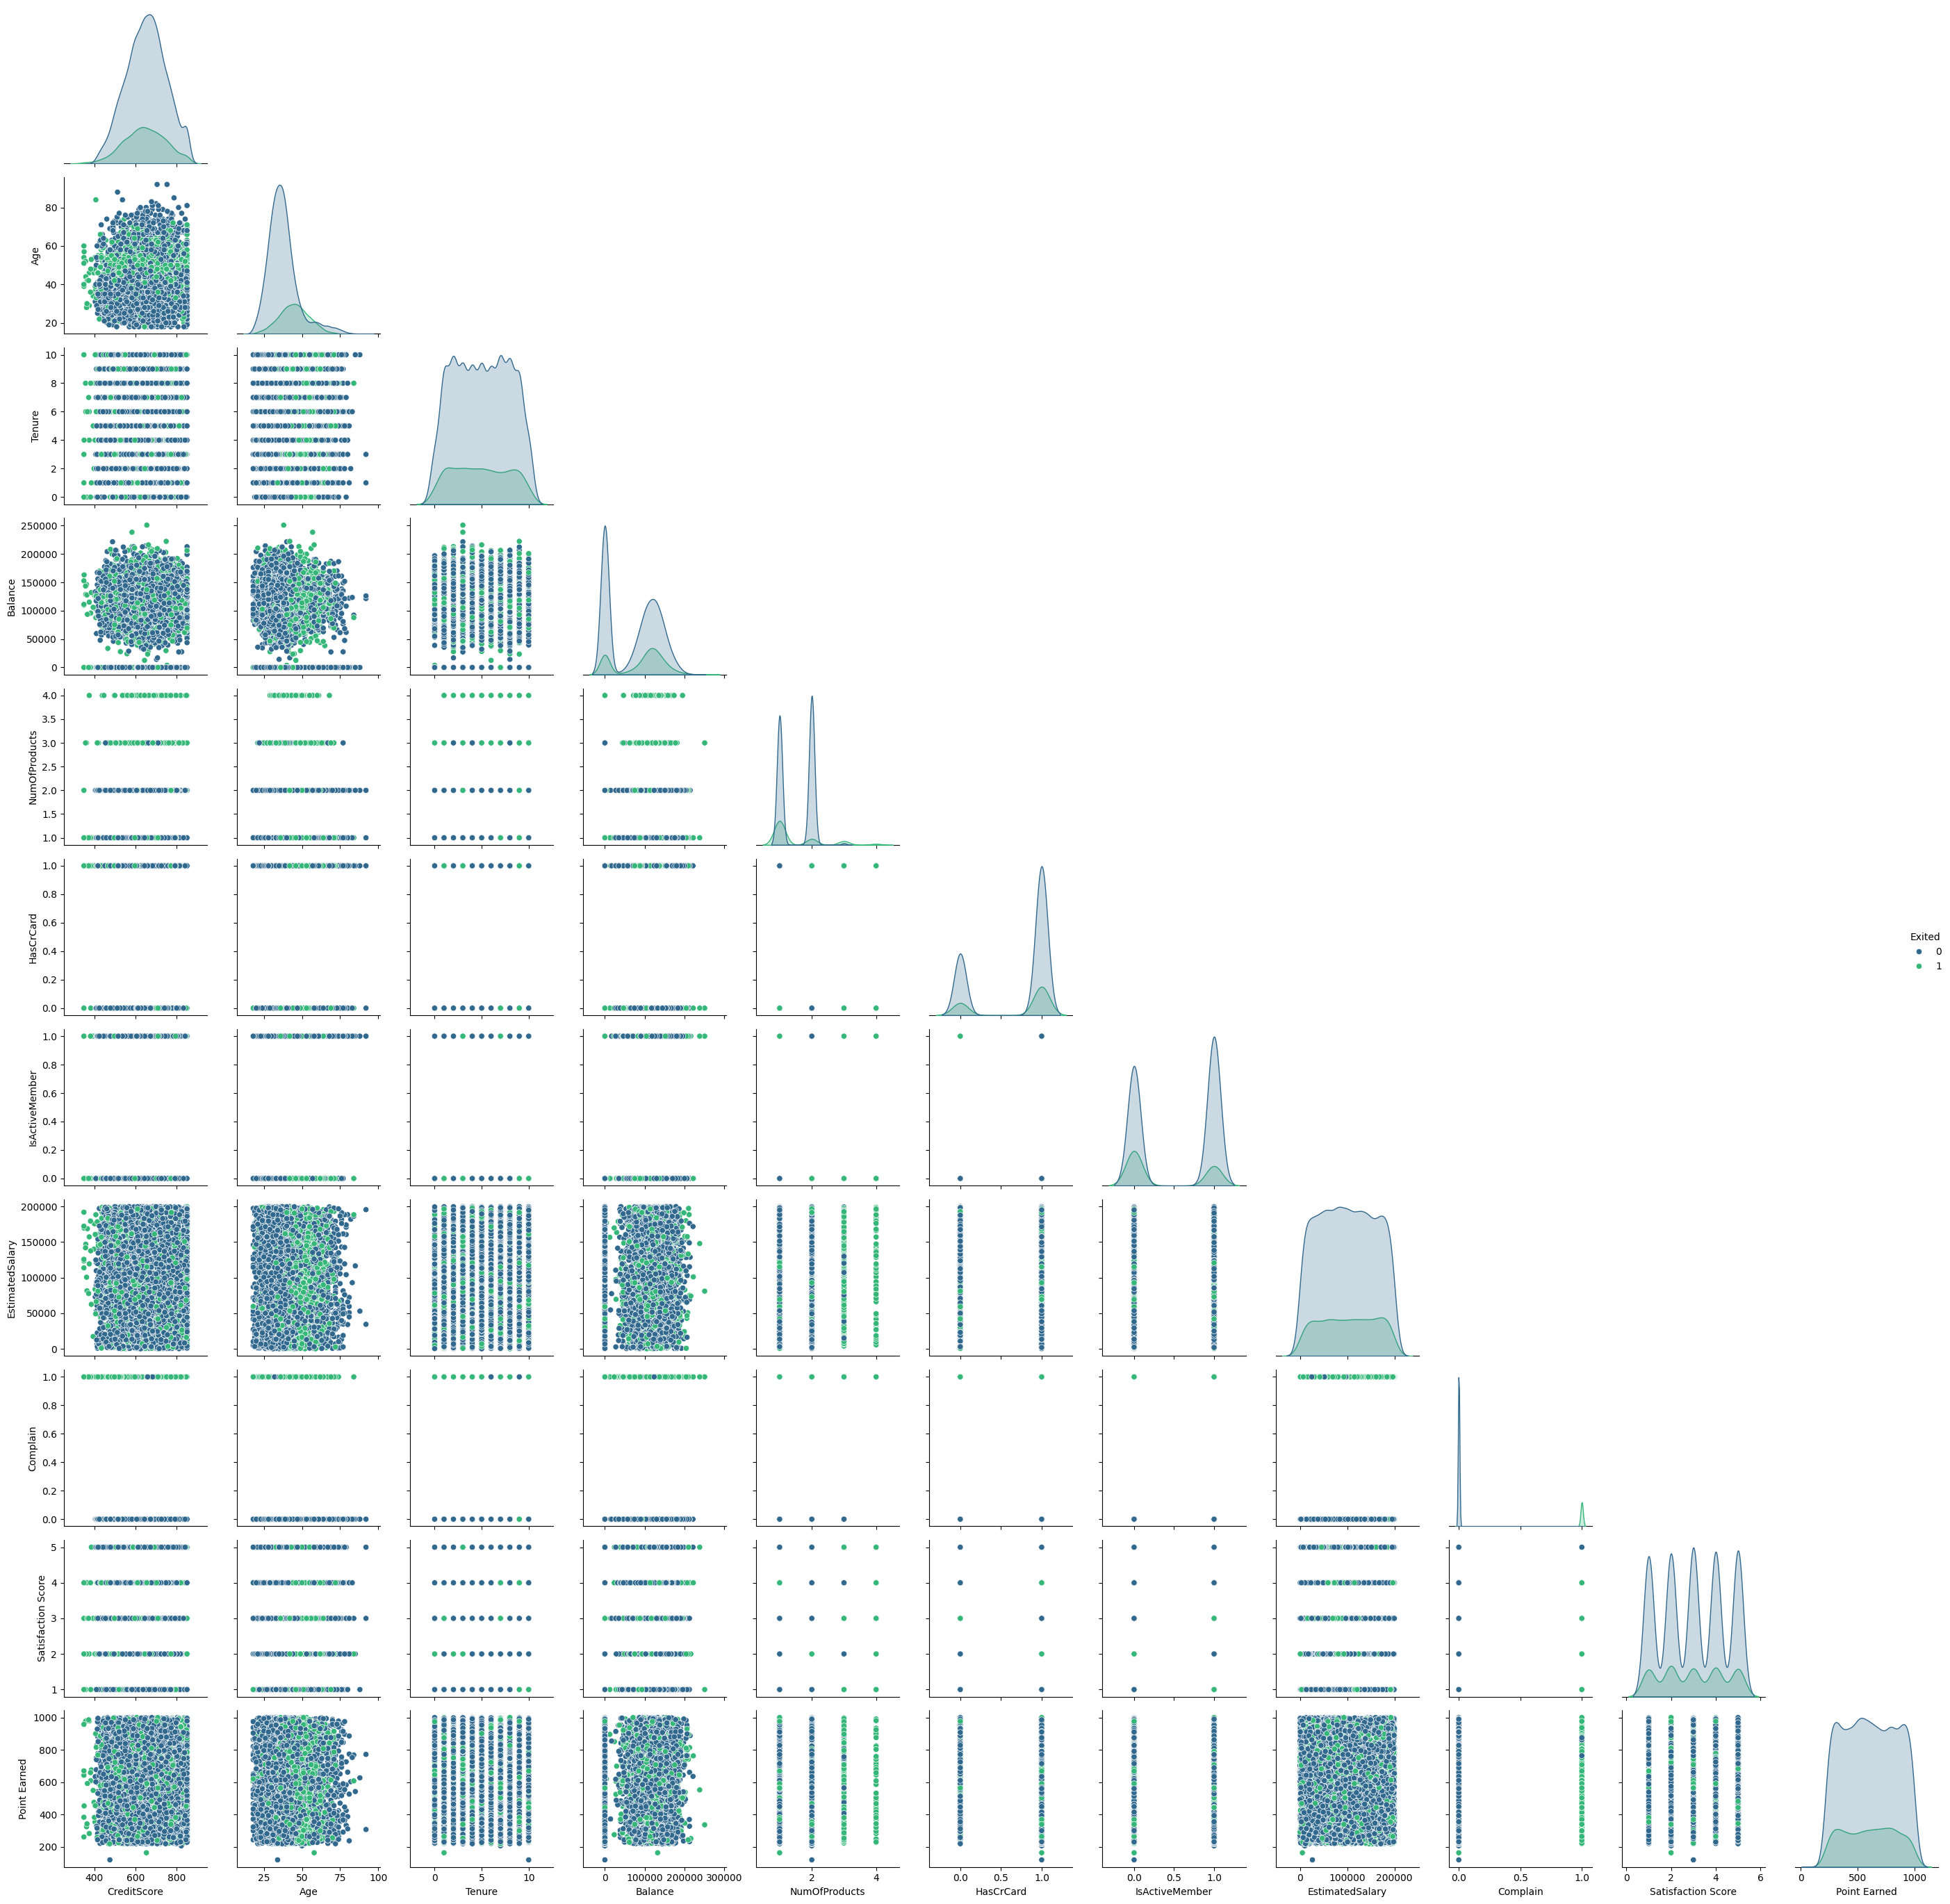

In [45]:
#======================================= ALL Dataset Distribution ====================================#
sns.pairplot(loan_df,hue = 'Exited',palette = 'viridis',corner = True)
plt.tight_layout()
plt.savefig("Dataset Distribution.png")
plt.show()

In [46]:
#=============================== Create A Automated EDA Report Using ydataProfiling ============================#
profile = ProfileReport(loan_df,explorative = True)
profile.to_file("Loan_EDA_Output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 82.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Create A ML Model**

In [47]:
#============================================ Feature Encoding ============================================#
categorical_columns = [
    "Geography",
    "Gender",
    "Card Type"
]
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Complain",
    "Satisfaction Score",
    "Point Earned"
]

In [48]:
#======================================= Create A Two Variable X and y =========================================#
X = loan_df[categorical_columns + numeric_columns]
y = loan_df['Exited']

In [49]:
#=================================== Create A Validtion Dataset Split ==========================================#
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [50]:
#====================================== Create A ColumnTransformer Object ======================================#
preprocessor = ColumnTransformer(transformers = [
    ('categorical_columns',OneHotEncoder(handle_unknown = 'ignore',drop = 'first'),categorical_columns),
    ('numeric_columns',StandardScaler(),numeric_columns)
])

In [51]:
#=========================================== Try Multiple Models ==============================================#
models = [
    ("LogisticRegression",LogisticRegression(max_iter = 1000)),
    ('DecisionTreeClassifier',DecisionTreeClassifier(random_state = 42)),
    ('RandomForestClassifier',RandomForestClassifier(random_state = 42)),
    ('GradientBoostingClassifier',GradientBoostingClassifier(random_state = 42)),
    ('XGBClassifier',XGBClassifier(random_state = 42)),
    ('CatBoostClassifier',CatBoostClassifier(random_state = 42,verbose=0)),
    ('LGBMClassifier',LGBMClassifier(random_state = 42,verbose=0 ))
]

In [52]:
#======================================= Create A Imblearn-Pipeline Object ====================================#
for name,model in models:
    pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('SMOTE',SMOTE(random_state = 42)),
        (name,model)
    ])
    pipeline.fit(x_train,y_train)
    y_pred = pipeline.predict(x_test)
    y_pred_proba = pipeline.predict_proba(x_test)[:,1]
    print(f"\n{'#' + '='*15} {name} {'='*15 + '#'}")
    print("#" + "="*40 + "#")
    print("Training Score Is: ",pipeline.score(x_train,y_train))
    print("#" + "="*40 + "#")
    print("Testing Score Is: ",pipeline.score(x_test,y_test))
    print("#" + "="*40 + "#")
    print("Accuracy Is: ", accuracy_score(y_test, y_pred))
    print("#" + "="*40 + "#")
    print(classification_report(y_test, y_pred))
    print("#" + "="*40 + "#")
    print("Confusion Matrix Is: \n", confusion_matrix(y_test, y_pred))
    print("#" + "="*40 + "#")
    print("ROC AUC Is: ", roc_auc_score(y_test, y_pred_proba))
    print("#" + "="*40 + "#\n")
    


#=============== LogisticRegression ===============#
#========================================#
Training Score Is:  0.998625
#========================================#
Testing Score Is:  0.9985
#========================================#
Accuracy Is:  0.9985
#========================================#
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

#========================================#
Confusion Matrix Is: 
 [[1591    1]
 [   2  406]]
#========================================#
ROC AUC Is:  0.9989454010247314
#========================================#


#=============== DecisionTreeClassifier ===============#
#========================================#
Training Score Is:  1.0
#=================================

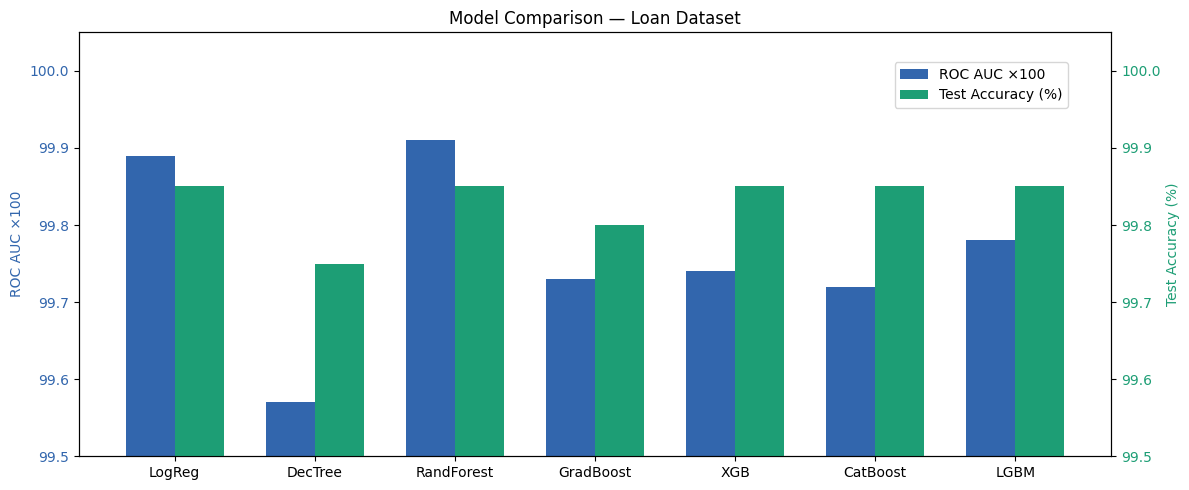

In [53]:
#==================================== Visualization Models Accuracy and Roc-auc-score ========================#

labels = ['LogReg', 'DecTree', 'RandForest', 'GradBoost', 'XGB', 'CatBoost', 'LGBM']
roc    = [99.89, 99.57, 99.91, 99.73, 99.74, 99.72, 99.78]
acc    = [99.85, 99.75, 99.85, 99.80, 99.85, 99.85, 99.85]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 5))

bars1 = ax1.bar(x - width/2, roc, width, label='ROC AUC ×100', color='#3266ad')
ax1.set_ylabel('ROC AUC ×100', color='#3266ad')
ax1.set_ylim(99.5, 100.05)
ax1.tick_params(axis='y', labelcolor='#3266ad')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, acc, width, label='Test Accuracy (%)', color='#1d9e75')
ax2.set_ylabel('Test Accuracy (%)', color='#1d9e75')
ax2.set_ylim(99.5, 100.05)
ax2.tick_params(axis='y', labelcolor='#1d9e75')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title('Model Comparison — Loan Dataset')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [54]:
#========================================== Feature Importants ==============================================#
x_translated = preprocessor.fit_transform(x_train,y_train)
features = preprocessor.get_feature_names_out()
x_df = pd.DataFrame(x_translated,columns = features)
x_df.corr()
x_df['Exited'] = y_train.values
x_df.corr()['Exited'].sort_values(ascending=False)

Exited                                     1.000000
numeric_columns__Complain                  0.995773
numeric_columns__Age                       0.280432
categorical_columns__Geography_germany     0.182070
numeric_columns__Balance                   0.120726
numeric_columns__EstimatedSalary           0.017851
categorical_columns__Card Type_platinum   -0.003506
numeric_columns__Satisfaction Score       -0.003726
categorical_columns__Card Type_silver     -0.004057
numeric_columns__Tenure                   -0.004108
numeric_columns__Point Earned             -0.012095
numeric_columns__HasCrCard                -0.016526
categorical_columns__Card Type_gold       -0.017979
numeric_columns__CreditScore              -0.030191
numeric_columns__NumOfProducts            -0.048662
categorical_columns__Geography_spain      -0.053763
categorical_columns__Gender_male          -0.106179
numeric_columns__IsActiveMember           -0.147864
Name: Exited, dtype: float64

In [55]:
#========================================== Final Model Is RandomForestClassifier ===========================#

In [56]:
#============================================== Save The Model ==============================================#
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('SMOTE', SMOTE(random_state=42)),
    ('RandomForest', RandomForestClassifier(random_state=42))
])

model_rf.fit(x_train, y_train)

joblib.dump(model_rf, 'random_forest_pipeline.pkl')

print("Model 'model_rf' saved")

Model 'model_rf' saved


In [57]:
#============================================= Download Pkl File ===============================================#
from IPython.display import FileLink
FileLink('random_forest_pipeline.pkl')

/kaggle/working/random_forest_pipeline.pkl


## 📊 Dataset Summary
- **Total Test Samples:** 2000  
- **Class 0 (Not Exited):** 1592  
- **Class 1 (Exited):** 408  

---
## 🏆 Best Model Performance
- Random Forest achieved the highest ROC-AUC (0.9991), making it the best overall performing model.
- Logistic Regression achieved the same high accuracy (99.85%) with a simpler and more interpretable structure, making it an excellent baseline and interpretable model.
- LightGBM provided strong performance (ROC-AUC ≈ 0.9978) with efficient gradient boosting, making it a fast and scalable model for large datasets.

---
## 📊 Dataset Insights
- The dataset contains 10,000 customer records used for predicting whether a customer will churn (Exited = 1) or stay (Exited = 0).
- The target variable Exited is moderately imbalanced:
79.62% customers stayed (Exited = 0)
20.38% customers churned (Exited = 1)
- The dataset includes demographic, financial, and account-related features such as customer age, balance, credit score, tenure, and number of products, which are commonly used to understand customer behavior and churn risk.
- Since the dataset is not extremely imbalanced, standard classification algorithms like Logistic Regression, Random Forest, Gradient Boosting, and XGBoost can perform effectively without heavy imbalance handling - techniques.
- The relatively balanced distribution allows the models to learn meaningful churn patterns, which helps achieve strong predictive performance.

---
## 💼 Business Impact
- False Negatives are costly → churn customers may leave without any retention action from the business.
- A model with higher predictive power (like Random Forest) improves the ability to accurately identify customers likely to churn.
- A balanced and interpretable model (like Logistic Regression) helps businesses understand the factors influencing churn and take targeted retention actions.

---
## 🏁 Final Recommendation
- ✅ Use Random Forest for the best overall predictive performance due to its highest ROC-AUC and strong ensemble stability.
- ✅ Use Logistic Regression when model interpretability is important, allowing easier explanation of churn factors to business stakeholders.
- ⚠️ Avoid relying solely on accuracy, and prioritize metrics such as ROC-AUC, recall, and false negatives, especially in churn prediction problems.

---
| Rank | Model               | ROC-AUC    | Accuracy   | False Negatives |
| ---- | ------------------- | ---------- | ---------- | --------------- |
| 1️⃣  | Random Forest       | **0.9991** | **99.85%** | 2               |
| 2️⃣  | Logistic Regression | 0.9989     | **99.85%** | 2               |
| 3️⃣  | LightGBM            | 0.9978     | **99.85%** | 2               |
| 4️⃣  | XGBoost             | 0.9974     | **99.85%** | 2               |
| 5️⃣  | Gradient Boosting   | 0.9973     | 99.80%     | 2               |
| 6️⃣  | CatBoost            | 0.9972     | **99.85%** | 2               |
| 7️⃣  | Decision Tree       | 0.9957     | 99.75%     | 3               |
